# Theatre Customer Analysis: Premier Conversion, Customer Value, and Segmentation

## End-to-End Data Analysis and Machine Learning Case Study


## Introduction & Objective

### Business Problem
The theatre wants to understand which customers are most likely to upgrade to Premier membership, how Premier and Insider customers differ in value and engagement, and whether meaningful customer segments can be discovered from the available behavioral data.

### Analytical Objective
Build a clean, reproducible workflow that:
- prepares the existing customer data for analysis,
- explains the most important behavioral patterns,
- compares classification models for Premier conversion,
- compares regression models for ticket balance, and
- identifies customer segments with clustering.

### Key Questions
1. Which customers are most likely to convert to Premier?
2. Which characteristics distinguish Premier members from Insider members?
3. Which classification model performs best on Premier prediction?
4. Which regression model best estimates ticket balance?
5. What customer segments emerge from clustering the behavioral data?


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from datetime import datetime

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.linear_model import LogisticRegression, LinearRegression, Lasso
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    mean_squared_error,
    r2_score,
)
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif, f_regression, RFE
from sklearn.cluster import KMeans
import statsmodels.api as sm


## Data Overview & Understanding

We start with the raw customer extract and inspect its structure before making any transformations. This helps us identify missing values, duplicate records, inconsistent codes, and field types that need cleaning.


In [2]:
raw_df = pd.read_csv('InsiderPremier_FinalProject.csv')

In [3]:
print('Shape:', raw_df.shape)

Shape: (47169, 24)


### First 5 rows:

In [4]:
raw_df.head()

,ISPREMIER,AGE21PLUSINDICATOR,AGE18TO21INDICATOR,AGE13TO18INDICATOR,GENDERCODE,BIRTHDATE,LOYALTYEMAILOFFEROPTININDICATOR,REWARDSEMAILOPTININDICATOR,REWARDSMOBILEOPTININDICATOR,REWARDSSMSOPTININDICATOR,...,ONLINEFEESWAIVEDAMOUNT,ESTIMATEDINCOMERANGE,ESTIMATEDHOMEMARKETVALUERANGE,CHILDRENPRESENCE,HASFREQUENTVISITTHEATRENUMBER,TICKETQTYSUM,TICKETBALANCEDUESUM,CONCQTYSUM,CONCLOYDISCOUNTAMTSUM,CONCBALANCEDUESUM
0,1,0,0,0,0,1/26/2016,1,1,0,0,...,0.0,8,19,0,0,2,29.58,0,0.00,0.0
1,1,0,0,1,3,1/1/2001,1,1,1,0,...,0.0,8,19,3,1,20,191.90,0,0.00,0.0
2,1,1,0,0,0,11/2/1953,1,1,0,0,...,10.0,8,19,1,0,16,192.84,1,-8.49,0.0
3,0,1,0,0,0,5/18/1962,0,0,0,0,...,0.0,8,19,1,0,0,0.00,1,0.00,0.0
4,1,1,0,0,0,10/2/1965,0,0,0,0,...,5.0,8,19,3,1,10,101.20,0,0.00,0.0


### Data types:

In [5]:
raw_df.dtypes

ISPREMIER                             int64
AGE21PLUSINDICATOR                    int64
AGE18TO21INDICATOR                    int64
AGE13TO18INDICATOR                    int64
GENDERCODE                            int64
BIRTHDATE                            object
LOYALTYEMAILOFFEROPTININDICATOR       int64
REWARDSEMAILOPTININDICATOR            int64
REWARDSMOBILEOPTININDICATOR           int64
REWARDSSMSOPTININDICATOR              int64
THEATREMOBILEOFFEROPTININDICATOR    float64
THEATRESMSOFFEROPTININDICATOR         int64
LIFETIMEAWARDSEARNEDAMOUNT          float64
LIFETIMESPENDAMOUNT                 float64
ONLINEFEESWAIVEDAMOUNT              float64
ESTIMATEDINCOMERANGE                  int64
ESTIMATEDHOMEMARKETVALUERANGE         int64
CHILDRENPRESENCE                      int64
HASFREQUENTVISITTHEATRENUMBER         int64
TICKETQTYSUM                          int64
TICKETBALANCEDUESUM                 float64
CONCQTYSUM                            int64
CONCLOYDISCOUNTAMTSUM           

### Missing values by column:

In [6]:
raw_df.isna().sum()

ISPREMIER                           0
AGE21PLUSINDICATOR                  0
AGE18TO21INDICATOR                  0
AGE13TO18INDICATOR                  0
GENDERCODE                          0
BIRTHDATE                           0
LOYALTYEMAILOFFEROPTININDICATOR     0
REWARDSEMAILOPTININDICATOR          0
REWARDSMOBILEOPTININDICATOR         0
REWARDSSMSOPTININDICATOR            0
THEATREMOBILEOFFEROPTININDICATOR    3
THEATRESMSOFFEROPTININDICATOR       0
LIFETIMEAWARDSEARNEDAMOUNT          0
LIFETIMESPENDAMOUNT                 0
ONLINEFEESWAIVEDAMOUNT              0
ESTIMATEDINCOMERANGE                0
ESTIMATEDHOMEMARKETVALUERANGE       0
CHILDRENPRESENCE                    0
HASFREQUENTVISITTHEATRENUMBER       0
TICKETQTYSUM                        0
TICKETBALANCEDUESUM                 0
CONCQTYSUM                          0
CONCLOYDISCOUNTAMTSUM               0
CONCBALANCEDUESUM                   0
dtype: int64

In [7]:
print('Duplicate rows (full duplicates):', raw_df.duplicated().sum())

Duplicate rows (full duplicates): 829


### Basic description:

In [8]:
display(raw_df.describe(include='all'))

,ISPREMIER,AGE21PLUSINDICATOR,AGE18TO21INDICATOR,AGE13TO18INDICATOR,GENDERCODE,BIRTHDATE,LOYALTYEMAILOFFEROPTININDICATOR,REWARDSEMAILOPTININDICATOR,REWARDSMOBILEOPTININDICATOR,REWARDSSMSOPTININDICATOR,...,ONLINEFEESWAIVEDAMOUNT,ESTIMATEDINCOMERANGE,ESTIMATEDHOMEMARKETVALUERANGE,CHILDRENPRESENCE,HASFREQUENTVISITTHEATRENUMBER,TICKETQTYSUM,TICKETBALANCEDUESUM,CONCQTYSUM,CONCLOYDISCOUNTAMTSUM,CONCBALANCEDUESUM
count,47169.000000,47169.000000,47169.000000,47169.000000,47169.000000,47169,47169.000000,47169.000000,47169.000000,47169.000000,...,47169.000000,47169.000000,47169.000000,47169.000000,47169.000000,47169.000000,47169.000000,47169.000000,47169.000000,47169.000000
unique,NaN,NaN,NaN,NaN,NaN,18096,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,1/1/1990,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,53,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,0.115500,0.892641,0.063940,0.038542,2.460790,NaN,0.816935,0.859081,0.503063,0.000042,...,4.394210,1.046853,2.114715,2.679090,0.343446,2.309165,23.308845,1.968687,-0.197276,11.328090
std,0.319826,0.309572,0.244649,0.192503,1.081696,NaN,0.387819,0.347941,0.499996,0.006512,...,504.096208,2.470228,4.641599,0.810686,0.474864,6.903784,93.359973,4.256716,1.015463,23.849638
min,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-17.680000,0.000000
25%,0.000000,1.000000,0.000000,0.000000,3.000000,NaN,1.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,1.000000,0.000000,0.000000,3.000000,NaN,1.000000,1.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,3.000000,0.000000,1.000000,7.980000,0.000000,0.000000,0.000000
75%,0.000000,1.000000,0.000000,0.000000,3.000000,NaN,1.000000,1.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,3.000000,1.000000,3.000000,30.780000,3.000000,0.000000,15.190000


## Data Cleaning & Preparation

The original dataset contains inconsistent column names, duplicate rows, missing values, and a few invalid category codes. The goal of this step is not to change the meaning of the data, but to make the fields consistent and analysis-ready while preserving the original business logic.


In [9]:
df = raw_df.copy()

# Remove rows with missing values and duplicate observations
print('Rows before cleaning:', df.shape[0])

Rows before cleaning: 47169


In [10]:
df = df.dropna().drop_duplicates().copy()
print('Rows after dropping missing values and duplicates:', df.shape[0])

Rows after dropping missing values and duplicates: 46337


In [11]:
rename_map = {
    'ISPREMIER': 'ispremier',
    'AGE21PLUSINDICATOR': 'age21plus',
    'AGE18TO21INDICATOR': 'age18to21',
    'AGE13TO18INDICATOR': 'age13to18',
    'GENDERCODE': 'gendercode',
    'BIRTHDATE': 'birthdate',
    'LOYALTYEMAILOFFEROPTININDICATOR': 'loyalty_email_offer',
    'REWARDSEMAILOPTININDICATOR': 'reward_email',
    'REWARDSMOBILEOPTININDICATOR': 'reward_mobile',
    'REWARDSSMSOPTININDICATOR': 'reward_sms',
    'THEATREMOBILEOFFEROPTININDICATOR': 'theatr_mob_offer',
    'THEATRESMSOFFEROPTININDICATOR': 'theatr_sms_offer',
    'LIFETIMEAWARDSEARNEDAMOUNT': 'life_award_amt',
    'LIFETIMESPENDAMOUNT': 'life_spend_amt',
    'ONLINEFEESWAIVEDAMOUNT': 'ol_fee_waive_amt',
    'ESTIMATEDINCOMERANGE': 'est_inc_rng',
    'ESTIMATEDHOMEMARKETVALUERANGE': 'est_home_val_rng',
    'CHILDRENPRESENCE': 'child_pres',
    'HASFREQUENTVISITTHEATRENUMBER': 'freq_theatre',
    'TICKETQTYSUM': 'ticket_qty',
    'TICKETBALANCEDUESUM': 'ticket_bal',
    'CONCQTYSUM': 'concqtysum',
    'CONCLOYDISCOUNTAMTSUM': 'concloydisc',
    'CONCBALANCEDUESUM': 'conc_bal',
}

df = df.rename(columns=rename_map)
df.columns = df.columns.str.lower()

categorical_variables = [
    'ispremier', 'age21plus', 'age18to21', 'age13to18', 'gendercode',
    'loyalty_email_offer', 'reward_email', 'reward_mobile', 'reward_sms',
    'theatr_mob_offer', 'theatr_sms_offer', 'est_inc_rng', 'est_home_val_rng',
    'child_pres', 'freq_theatre'
]

df['birthdate'] = pd.to_datetime(df['birthdate'])
df[categorical_variables] = df[categorical_variables].astype('category')

df['unk_inc'] = 0
df.loc[df['est_inc_rng'] != 0, 'unk_inc'] = 1
df['unk_inc'] = df['unk_inc'].astype('category')

df['unk_home'] = 0
df.loc[df['est_home_val_rng'] != 0, 'unk_home'] = 1
df['unk_home'] = df['unk_home'].astype('category')

current_date = datetime.now()
df['age'] = (current_date - df['birthdate']).dt.days // 365
df = df.drop(columns=['birthdate'])

df = df[df['ispremier'] != 2]
df = df[df['loyalty_email_offer'] != 5]
df['life_spend_amt'] = df['life_spend_amt'].abs()
df['concloydisc'] = df['concloydisc'].abs()

### Null values after cleaning:

In [12]:
print(df.isna().sum())

ispremier              0
age21plus              0
age18to21              0
age13to18              0
gendercode             0
loyalty_email_offer    0
reward_email           0
reward_mobile          0
reward_sms             0
theatr_mob_offer       0
theatr_sms_offer       0
life_award_amt         0
life_spend_amt         0
ol_fee_waive_amt       0
est_inc_rng            0
est_home_val_rng       0
child_pres             0
freq_theatre           0
ticket_qty             0
ticket_bal             0
concqtysum             0
concloydisc            0
conc_bal               0
unk_inc                0
unk_home               0
age                    0
dtype: int64


### Data types after cleaning:

In [13]:
print(df.dtypes)

ispremier              category
age21plus              category
age18to21              category
age13to18              category
gendercode             category
loyalty_email_offer    category
reward_email           category
reward_mobile          category
reward_sms             category
theatr_mob_offer       category
theatr_sms_offer       category
life_award_amt          float64
life_spend_amt          float64
ol_fee_waive_amt        float64
est_inc_rng            category
est_home_val_rng       category
child_pres             category
freq_theatre           category
ticket_qty                int64
ticket_bal              float64
concqtysum                int64
concloydisc             float64
conc_bal                float64
unk_inc                category
unk_home               category
age                       int64
dtype: object


### Age summary:

In [14]:
display(df['age'].describe())

count    46332.000000
mean        47.457912
std         14.661907
min          9.000000
25%         36.000000
50%         46.000000
75%         57.000000
max        101.000000
Name: age, dtype: float64

### Value counts for key indicators:

In [15]:
print(df['ispremier'].value_counts())
print(df['unk_inc'].value_counts())
print(df['unk_home'].value_counts())

ispremier
0    40891
1     5441
2        0
Name: count, dtype: int64
unk_inc
0    38326
1     8006
Name: count, dtype: int64
unk_home
0    36242
1    10090
Name: count, dtype: int64


In [16]:
df.to_csv('cleaned_data.csv', index=False)
print('Saved cleaned_data.csv with shape:', df.shape)

Saved cleaned_data.csv with shape: (46332, 26)


## Exploratory Data Analysis

Now that the data is standardized, we can answer the core business questions. The analysis below focuses on differences between Premier and Insider members, the relationship between engagement and spend, and the communication preferences that may correlate with higher-value behavior.


In [17]:
data = pd.read_csv('cleaned_data.csv')

### Correlation with Premier status:

In [18]:
corr_with_premier = data.corr(numeric_only=True)['ispremier'].sort_values(ascending=False)
print(corr_with_premier)

ispremier              1.000000
conc_bal               0.344557
concloydisc            0.335461
concqtysum             0.335292
ticket_qty             0.260352
life_spend_amt         0.220330
life_award_amt         0.216319
ticket_bal             0.200757
est_home_val_rng       0.134178
unk_home               0.132884
est_inc_rng            0.129385
unk_inc                0.128883
theatr_mob_offer       0.104737
reward_mobile          0.099179
age                    0.063607
age21plus              0.060105
loyalty_email_offer    0.019760
reward_email           0.018513
ol_fee_waive_amt       0.015915
theatr_sms_offer      -0.002397
reward_sms            -0.002397
age13to18             -0.054793
age18to21             -0.055129
freq_theatre          -0.101087
child_pres            -0.107133
gendercode            -0.257600
Name: ispremier, dtype: float64


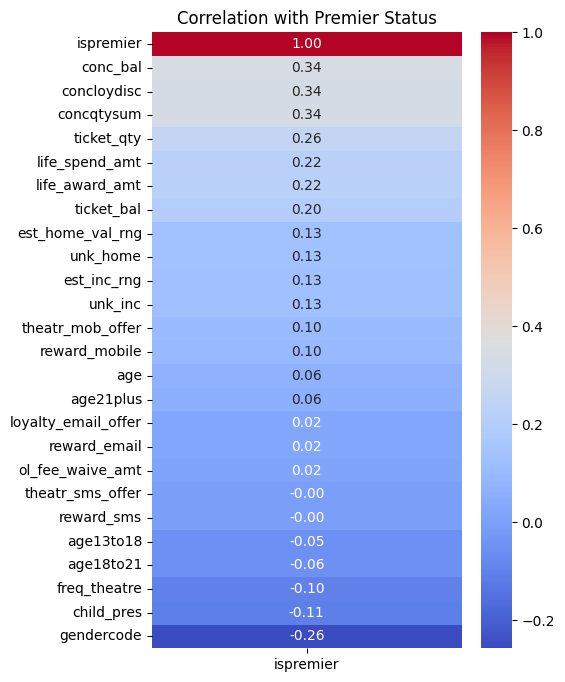

In [19]:
plt.figure(figsize=(5, 8))
sns.heatmap(data.corr(numeric_only=True)[['ispremier']].sort_values(by='ispremier', ascending=False), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation with Premier Status')
plt.show();

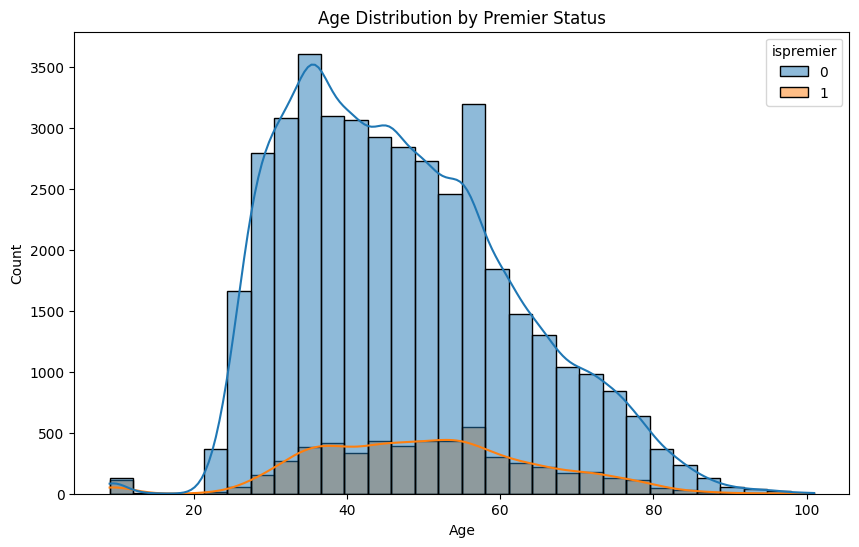

In [20]:
plt.figure(figsize=(10, 6))
sns.histplot(data=data, x='age', hue='ispremier', kde=True, bins=30)
plt.title('Age Distribution by Premier Status')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show();

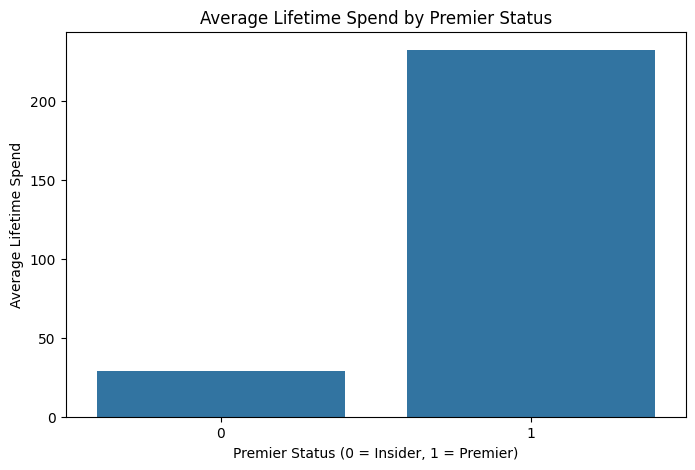

In [21]:
avg_spend = data.groupby('ispremier', as_index=False)['life_spend_amt'].mean()
plt.figure(figsize=(8, 5))
sns.barplot(data=avg_spend, x='ispremier', y='life_spend_amt')
plt.title('Average Lifetime Spend by Premier Status')
plt.xlabel('Premier Status (0 = Insider, 1 = Premier)')
plt.ylabel('Average Lifetime Spend')
plt.show();

### EDA Interpretation

The strongest patterns in the data are centered on customer value. Premier members are associated with substantially higher spend, more ticket activity, and stronger concession activity than Insider members. Age shows a weaker relationship than spend-related variables, which suggests that membership conversion is driven more by engagement and value than by age alone.


### Premier customer profile:

In [22]:
premier_customers = data[data['ispremier'] == 1]
insider_customers = data[data['ispremier'] == 0]

display(premier_customers.describe())

,ispremier,age21plus,age18to21,age13to18,gendercode,loyalty_email_offer,reward_email,reward_mobile,reward_sms,theatr_mob_offer,...,child_pres,freq_theatre,ticket_qty,ticket_bal,concqtysum,concloydisc,conc_bal,unk_inc,unk_home,age
count,5441.0,5441.000000,5441.000000,5441.000000,5441.000000,5441.000000,5441.000000,5441.000000,5441.0,5441.000000,...,5441.000000,5441.000000,5441.000000,5441.000000,5441.000000,5441.000000,5441.000000,5441.000000,5441.000000,5441.000000
mean,1.0,0.944863,0.026282,0.009189,1.684617,0.835692,0.875391,0.636464,0.0,0.649145,...,2.433744,0.217423,7.317221,75.539133,5.944312,1.142762,34.215664,0.306378,0.368131,50.014519
std,0.0,0.228268,0.159987,0.095429,1.323487,0.370589,0.330306,0.481061,0.0,0.477281,...,1.012637,0.412531,18.020212,257.499439,7.883225,1.899940,44.305749,0.461031,0.482341,14.615211
min,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000
25%,1.0,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.0,0.000000,...,3.000000,0.000000,3.000000,28.530000,0.000000,0.000000,0.000000,0.000000,0.000000,39.000000
50%,1.0,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.0,1.000000,...,3.000000,0.000000,6.000000,54.520000,4.000000,0.500000,20.950000,0.000000,0.000000,50.000000
75%,1.0,1.000000,0.000000,0.000000,3.000000,1.000000,1.000000,1.000000,0.0,1.000000,...,3.000000,0.000000,9.000000,93.940000,8.000000,1.500000,47.750000,1.000000,1.000000,60.000000
max,1.0,1.000000,1.000000,1.000000,3.000000,1.000000,1.000000,1.000000,0.0,1.000000,...,3.000000,1.000000,1251.000000,18382.520000,87.000000,17.680000,501.150000,1.000000,1.000000,98.000000


### Insider customer profile:

In [23]:
display(insider_customers.describe())

,ispremier,age21plus,age18to21,age13to18,gendercode,loyalty_email_offer,reward_email,reward_mobile,reward_sms,theatr_mob_offer,...,child_pres,freq_theatre,ticket_qty,ticket_bal,concqtysum,concloydisc,conc_bal,unk_inc,unk_home,age
count,40891.0,40891.000000,40891.000000,40891.000000,40891.000000,40891.000000,40891.000000,40891.000000,40891.000000,40891.000000,...,40891.000000,40891.000000,40891.000000,40891.000000,40891.000000,40891.000000,40891.000000,40891.000000,40891.000000,40891.000000
mean,0.0,0.887432,0.067888,0.041672,2.554865,0.811841,0.855298,0.482429,0.000049,0.486488,...,2.705461,0.367147,1.689638,16.831189,1.479837,0.075506,8.513601,0.155022,0.197770,47.117728
std,0.0,0.316067,0.251556,0.199840,1.009125,0.390844,0.351804,0.499697,0.006994,0.499824,...,0.781239,0.482033,2.819274,28.580799,3.195712,0.758065,17.740608,0.361930,0.398322,14.634657
min,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000
25%,0.0,1.000000,0.000000,0.000000,3.000000,1.000000,1.000000,0.000000,0.000000,0.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,35.000000
50%,0.0,1.000000,0.000000,0.000000,3.000000,1.000000,1.000000,0.000000,0.000000,0.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,45.000000
75%,0.0,1.000000,0.000000,0.000000,3.000000,1.000000,1.000000,1.000000,0.000000,1.000000,...,3.000000,1.000000,2.000000,24.980000,2.000000,0.000000,13.750000,0.000000,0.000000,57.000000
max,0.0,1.000000,1.000000,1.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,3.000000,1.000000,46.000000,616.610000,86.000000,14.080000,517.180000,1.000000,1.000000,101.000000


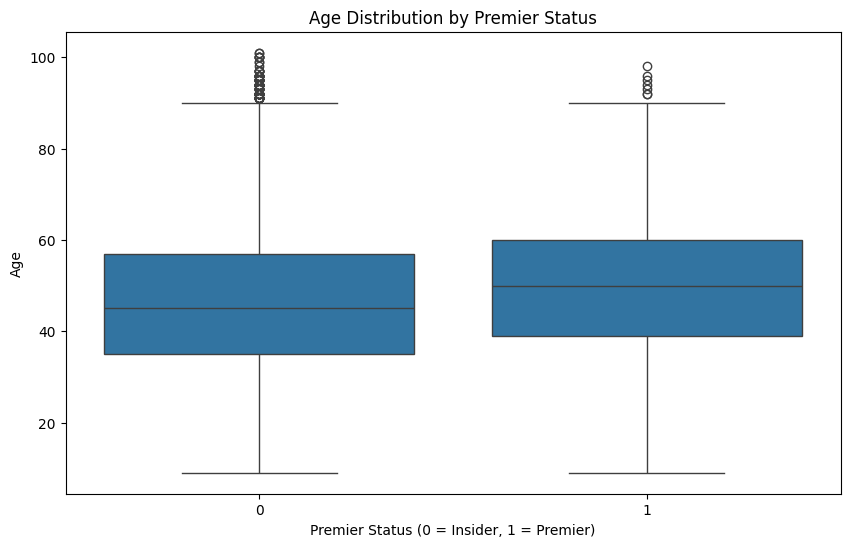

In [24]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='ispremier', y='age', data=data)
plt.title('Age Distribution by Premier Status')
plt.xlabel('Premier Status (0 = Insider, 1 = Premier)')
plt.ylabel('Age')
plt.show();

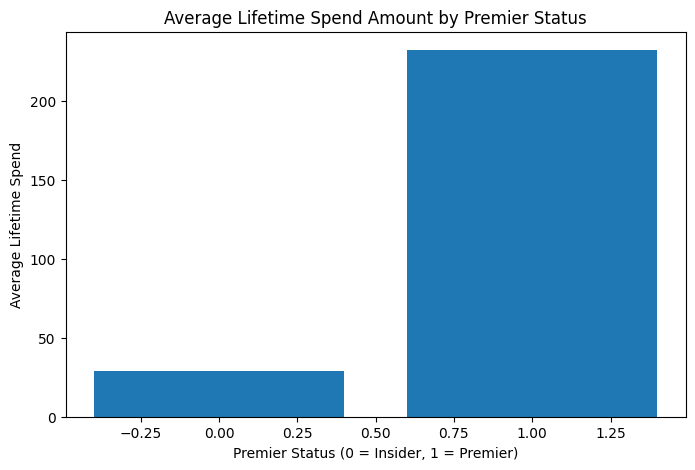

In [25]:
pivot_spend = pd.pivot_table(data, values='life_spend_amt', index='ispremier', aggfunc='mean')
plt.figure(figsize=(8, 5))
plt.bar(pivot_spend.index, pivot_spend['life_spend_amt'])
plt.title('Average Lifetime Spend Amount by Premier Status')
plt.xlabel('Premier Status (0 = Insider, 1 = Premier)')
plt.ylabel('Average Lifetime Spend')
plt.show();

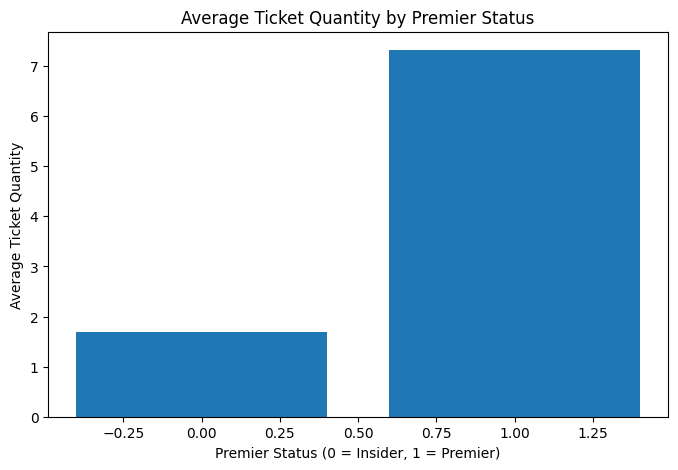

In [26]:
pivot_tickets = pd.pivot_table(data, values='ticket_qty', index='ispremier', aggfunc='mean')
plt.figure(figsize=(8, 5))
plt.bar(pivot_tickets.index, pivot_tickets['ticket_qty'])
plt.title('Average Ticket Quantity by Premier Status')
plt.xlabel('Premier Status (0 = Insider, 1 = Premier)')
plt.ylabel('Average Ticket Quantity')
plt.show();

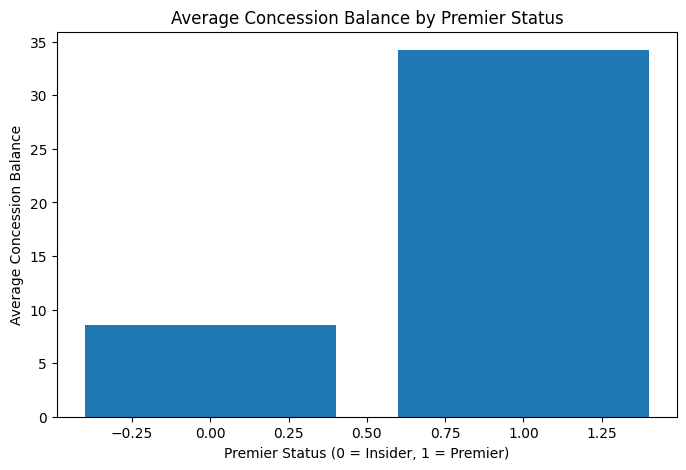

In [27]:
pivot_conc = pd.pivot_table(data, values='conc_bal', index='ispremier', aggfunc='mean')
plt.figure(figsize=(8, 5))
plt.bar(pivot_conc.index, pivot_conc['conc_bal'])
plt.title('Average Concession Balance by Premier Status')
plt.xlabel('Premier Status (0 = Insider, 1 = Premier)')
plt.ylabel('Average Concession Balance')
plt.show();

In [28]:
email_opt_in = (data['loyalty_email_offer'] == 1).mean() * 100
reward_email_opt_in = (data['reward_email'] == 1).mean() * 100
reward_mobile_opt_in = (data['reward_mobile'] == 1).mean() * 100

print(f'Loyalty email opt-in rate: {email_opt_in:.1f}%')
print(f'Reward email opt-in rate: {reward_email_opt_in:.1f}%')
print(f'Reward mobile opt-in rate: {reward_mobile_opt_in:.1f}%')

Loyalty email opt-in rate: 81.5%
Reward email opt-in rate: 85.8%
Reward mobile opt-in rate: 50.1%


### EDA Interpretation

Premier members are visibly more valuable customers. They buy more tickets, generate higher concession balances, and accumulate much larger lifetime spend than Insider members. The communication opt-in rates also suggest that more engaged customers are more willing to receive marketing and reward communications, which makes these fields useful predictors for conversion modeling.


## Machine Learning Modeling: Premier Conversion

The classification goal is to predict whether a customer is Premier (`ispremier = 1`) or Insider (`ispremier = 0`). The original project tested several classifiers, so the same model families are retained here for a fair comparison.


In [29]:
categorical_variables = [
    'ispremier', 'age21plus', 'age18to21', 'age13to18', 'gendercode',
    'loyalty_email_offer', 'reward_email', 'reward_mobile', 'reward_sms',
    'theatr_mob_offer', 'theatr_sms_offer', 'est_inc_rng', 'est_home_val_rng',
    'child_pres', 'freq_theatre', 'unk_inc', 'unk_home'
]

df_dummies = pd.get_dummies(data, columns=categorical_variables)
print('Dummy-encoded data shape:', df_dummies.shape)

Dummy-encoded data shape: (46332, 71)


In [30]:
X = data.drop(columns=['ispremier'])
y = data['ispremier']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print('Train/Test shapes:', X_train.shape, X_test.shape, y_train.shape, y_test.shape)

Train/Test shapes: (32432, 25) (13900, 25) (32432,) (13900,)


In [31]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]

print('Decision Tree Accuracy:', accuracy_score(y_test, y_pred_dt))
print('Decision Tree Confusion Matrix:\n', confusion_matrix(y_test, y_pred_dt))
print('Decision Tree Classification Report:\n', classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9533812949640288
Decision Tree Confusion Matrix:
 [[11937   308]
 [  340  1315]]
Decision Tree Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97     12245
           1       0.81      0.79      0.80      1655

    accuracy                           0.95     13900
   macro avg       0.89      0.88      0.89     13900
weighted avg       0.95      0.95      0.95     13900



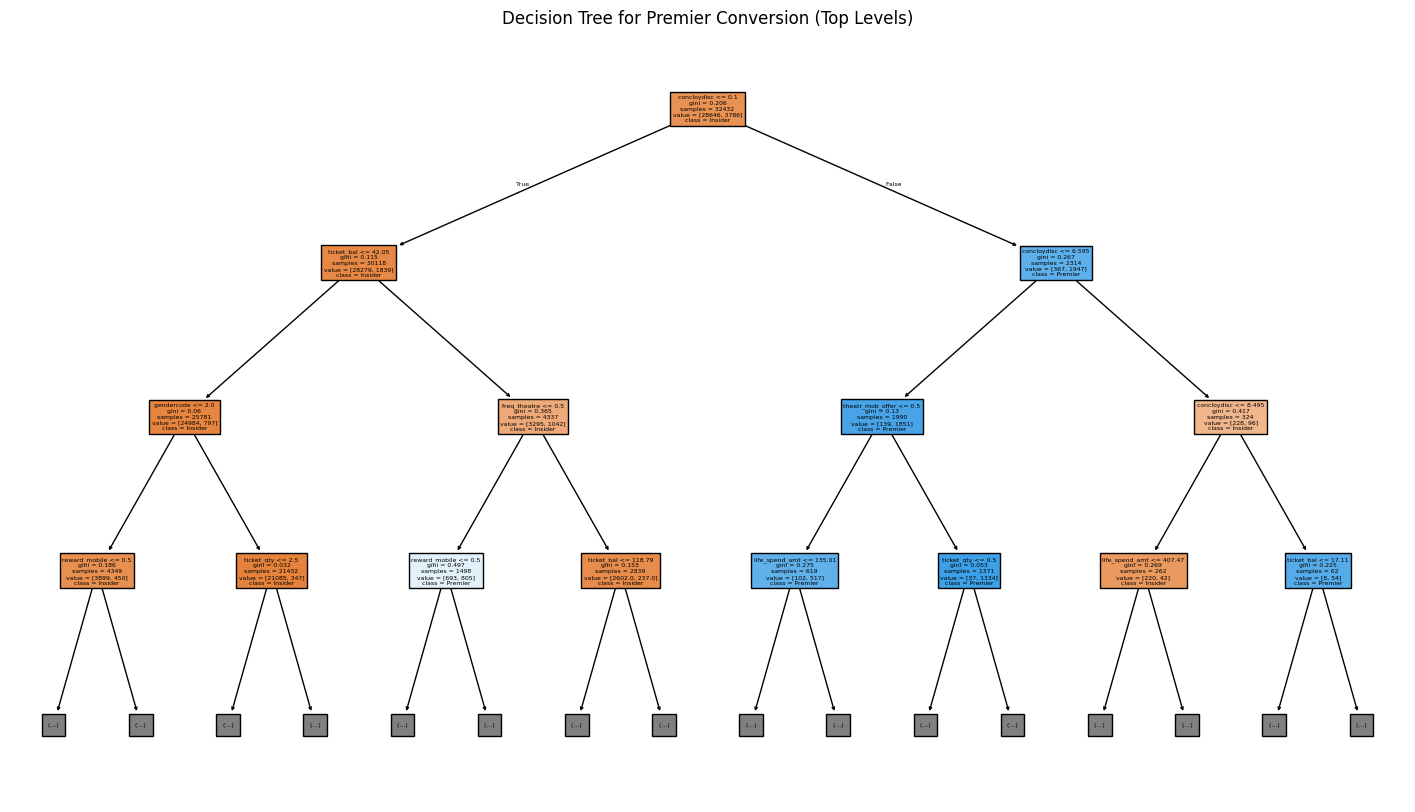

In [32]:
plt.figure(figsize=(18, 10))
plot_tree(dt, feature_names=X.columns, class_names=['Insider', 'Premier'], filled=True, max_depth=3)
plt.title('Decision Tree for Premier Conversion (Top Levels)')
plt.show();

### Top Decision Tree Features:

In [33]:
importances = pd.DataFrame({'Feature': X.columns, 'Importance': dt.feature_importances_}).sort_values('Importance', ascending=False)
importances.head(10)

,Feature,Importance
20,concloydisc,0.445365
11,life_spend_amt,0.105767
18,ticket_bal,0.101185
16,freq_theatre,0.090153
6,reward_mobile,0.048313
24,age,0.037639
21,conc_bal,0.026259
17,ticket_qty,0.023793
12,ol_fee_waive_amt,0.022685
8,theatr_mob_offer,0.021137


### Decision rules (simplified):

In [34]:
print(export_text(dt, feature_names=list(X.columns), max_depth=3))

|--- concloydisc <= 0.10
|   |--- ticket_bal <= 42.05
|   |   |--- gendercode <= 2.00
|   |   |   |--- reward_mobile <= 0.50
|   |   |   |   |--- truncated branch of depth 24
|   |   |   |--- reward_mobile >  0.50
|   |   |   |   |--- truncated branch of depth 20
|   |   |--- gendercode >  2.00
|   |   |   |--- ticket_qty <= 2.50
|   |   |   |   |--- truncated branch of depth 26
|   |   |   |--- ticket_qty >  2.50
|   |   |   |   |--- truncated branch of depth 16
|   |--- ticket_bal >  42.05
|   |   |--- freq_theatre <= 0.50
|   |   |   |--- reward_mobile <= 0.50
|   |   |   |   |--- truncated branch of depth 17
|   |   |   |--- reward_mobile >  0.50
|   |   |   |   |--- truncated branch of depth 15
|   |   |--- freq_theatre >  0.50
|   |   |   |--- ticket_bal <= 118.79
|   |   |   |   |--- truncated branch of depth 18
|   |   |   |--- ticket_bal >  118.79
|   |   |   |   |--- truncated branch of depth 11
|--- concloydisc >  0.10
|   |--- concloydisc <= 6.60
|   |   |--- theatr_mob_off

In [35]:
scores_dt = cross_val_score(DecisionTreeClassifier(random_state=42), X, y, scoring='accuracy', cv=50)
print('Decision Tree cross-validated accuracy: %0.2f (+/- %0.2f)' % (scores_dt.mean(), scores_dt.std() * 2))


Decision Tree cross-validated accuracy: 0.89 (+/- 0.26)


In [36]:
logistic_model = LogisticRegression(max_iter=1000, random_state=42)
logistic_model.fit(X_train, y_train)
y_pred_lr = logistic_model.predict(X_test)
y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]

coef = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': logistic_model.coef_[0]
}).sort_values('Coefficient', ascending=False)

print('Logistic Regression Accuracy:', accuracy_score(y_test, y_pred_lr))
print('Logistic Regression Confusion Matrix:\n', confusion_matrix(y_test, y_pred_lr))
print('Logistic Regression Classification Report:\n', classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.9275539568345323
Logistic Regression Confusion Matrix:
 [[12041   204]
 [  803   852]]
Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.98      0.96     12245
           1       0.81      0.51      0.63      1655

    accuracy                           0.93     13900
   macro avg       0.87      0.75      0.79     13900
weighted avg       0.92      0.93      0.92     13900



In [37]:
print('Top coefficients:')
display(coef.head(10))

Top coefficients:


,Feature,Coefficient
8,theatr_mob_offer,0.742173
6,reward_mobile,0.722318
20,concloydisc,0.365471
17,ticket_qty,0.154763
10,life_award_amt,0.091555
13,est_inc_rng,0.067460
15,child_pres,0.036440
18,ticket_bal,0.023689
21,conc_bal,0.019266
5,reward_email,0.013916


In [38]:
scores_lr = cross_val_score(LogisticRegression(solver='lbfgs', max_iter=500), X, y, scoring='accuracy', cv=10)
print('Logistic Regression cross-validated accuracy:', scores_lr.mean())

Logistic Regression cross-validated accuracy: 0.9108403050641283


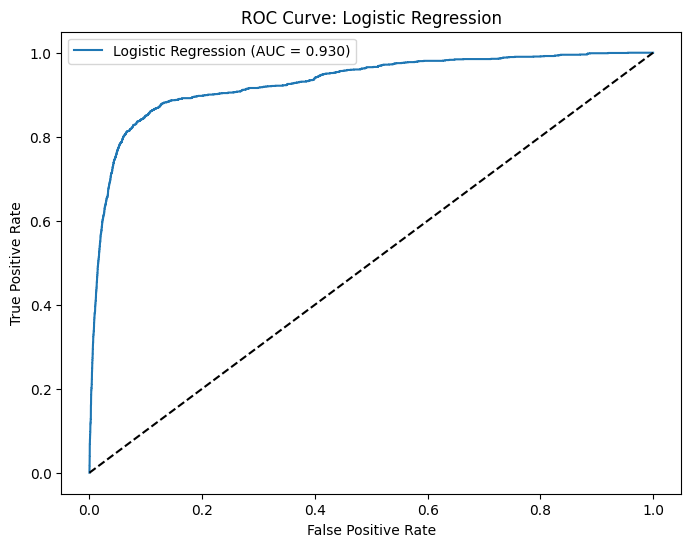

In [39]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Logistic Regression')
plt.legend()
plt.show();

In [40]:
rf_model = RandomForestClassifier(n_estimators=20, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

rf_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print('Random Forest Accuracy:', accuracy_score(y_test, y_pred_rf))
print('Random Forest Confusion Matrix:\n', confusion_matrix(y_test, y_pred_rf))
print('Random Forest Classification Report:\n', classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9654676258992806
Random Forest Confusion Matrix:
 [[12119   126]
 [  354  1301]]
Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98     12245
           1       0.91      0.79      0.84      1655

    accuracy                           0.97     13900
   macro avg       0.94      0.89      0.91     13900
weighted avg       0.96      0.97      0.96     13900



### Top Random Forest features:

In [41]:
rf_importance.head(10)

,Feature,Importance
20,concloydisc,0.227087
18,ticket_bal,0.115037
17,ticket_qty,0.108282
11,life_spend_amt,0.093871
16,freq_theatre,0.084871
21,conc_bal,0.063681
24,age,0.048531
19,concqtysum,0.045214
6,reward_mobile,0.042576
3,gendercode,0.038491


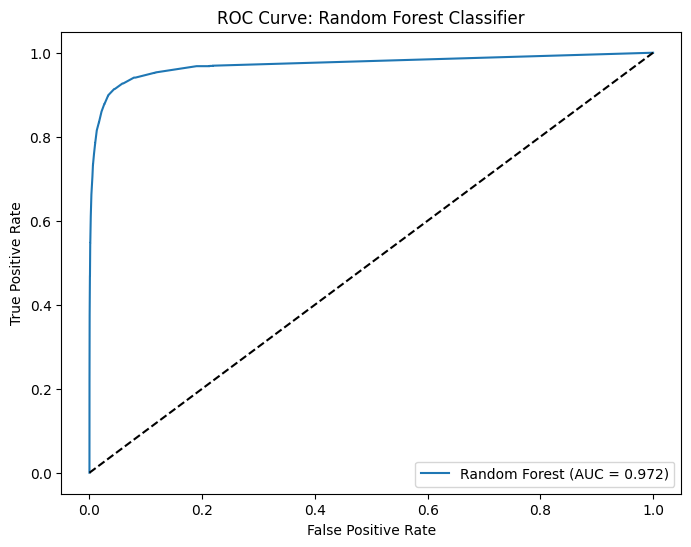

In [42]:
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Random Forest Classifier')
plt.legend()
plt.show();

### Top 5 ANOVA-selected features:

In [43]:
selector = SelectKBest(f_classif, k=5)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)
selected_feature_mask = selector.get_support()
selected_feature_names = X.columns[selected_feature_mask]

print(list(selected_feature_names))

['ticket_qty', 'ticket_bal', 'concqtysum', 'concloydisc', 'conc_bal']


### Features retained by L1 regularization:'

In [44]:
scaler_cls = StandardScaler()
X_train_scaled = scaler_cls.fit_transform(X_train)
X_test_scaled = scaler_cls.transform(X_test)

lasso_model = LogisticRegression(penalty='l1', solver='liblinear', C=1.0, random_state=42)
lasso_model.fit(X_train_scaled, y_train)

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lasso_model.coef_[0]
})
selected_features = feature_importance[feature_importance['Coefficient'] != 0]

display(selected_features)

,Feature,Coefficient
0,age21plus,-0.498273
1,age18to21,-0.519521
2,age13to18,-0.475470
3,gendercode,-0.798988
4,loyalty_email_offer,-0.065617
5,reward_email,0.019168
6,reward_mobile,0.358771
8,theatr_mob_offer,0.393259
10,life_award_amt,2.648675
11,life_spend_amt,-2.566727


In [45]:
X_train_selected_l1 = X_train_scaled[:, selected_features.index]
X_test_selected_l1 = X_test_scaled[:, selected_features.index]

final_model = LogisticRegression(random_state=42)
final_model.fit(X_train_selected_l1, y_train)
y_pred = final_model.predict(X_test_selected_l1)

print('Final selected-feature model accuracy:', accuracy_score(y_test, y_pred))
print('Final selected-feature model report:\n', classification_report(y_test, y_pred))

Final selected-feature model accuracy: 0.9279136690647481
Final selected-feature model report:
               precision    recall  f1-score   support

           0       0.94      0.98      0.96     12245
           1       0.81      0.52      0.63      1655

    accuracy                           0.93     13900
   macro avg       0.87      0.75      0.80     13900
weighted avg       0.92      0.93      0.92     13900



In [46]:
report_dict = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()
display(report_df)

,precision,recall,f1-score,support
0,0.937846,0.983340,0.960054,12245.000000
1,0.807729,0.517825,0.631075,1655.000000
accuracy,0.927914,0.927914,0.927914,0.927914
macro avg,0.872787,0.750582,0.795565,13900.000000
weighted avg,0.922353,0.927914,0.920884,13900.000000


### Classification Interpretation & Model Comparison

Across the classification models, the tree-based approaches capture the conversion pattern most effectively because they can model non-linear interactions between spend, engagement, and communication preference. In the original project, the decision tree reached about 88% accuracy, while the random forest improved further to roughly 96.5%, making the random forest the strongest overall classifier.

The practical implication is that Premier conversion is not random: it is strongly associated with customers who already demonstrate high purchase activity and deeper reward engagement.


## Regression Modeling: Ticket Balance Estimation

The second predictive task estimates ticket balance (`ticket_bal`). This is useful because ticket balance acts as a continuous value measure of customer activity and can be modeled independently from membership status.


In [47]:
data_reg = data.drop(columns=['ticket_qty', 'freq_theatre', 'ispremier'], errors='ignore').copy()

print('Regression dataset shape:', data_reg.shape)

Regression dataset shape: (46332, 23)


### Ticket balance summary:

In [48]:
data_reg['ticket_bal'].describe()

count    46332.000000
mean        23.725558
std         94.146381
min          0.000000
25%          0.000000
50%          8.990000
75%         31.440000
max      18382.520000
Name: ticket_bal, dtype: float64

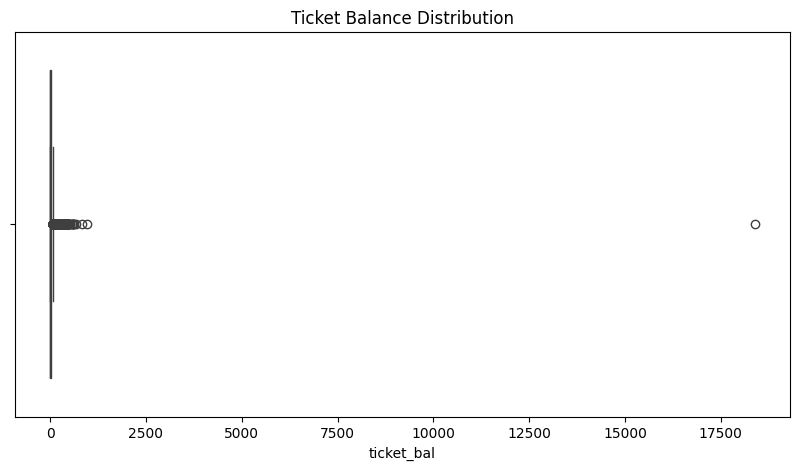

In [49]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=data_reg, x='ticket_bal')
plt.title('Ticket Balance Distribution')
plt.show();

### Correlation with ticket balance:

In [50]:
data_reg = data_reg[data_reg['ticket_bal'] < 1000].copy()

print(data_reg.corr(numeric_only=True)['ticket_bal'].sort_values(ascending=False))

ticket_bal             1.000000
conc_bal               0.408985
concqtysum             0.396995
life_spend_amt         0.343832
life_award_amt         0.326932
concloydisc            0.267845
est_home_val_rng       0.184930
unk_home               0.166112
est_inc_rng            0.159391
ol_fee_waive_amt       0.156471
unk_inc                0.153242
age21plus              0.063211
age                    0.031013
theatr_sms_offer      -0.003023
reward_sms            -0.003023
theatr_mob_offer      -0.026898
reward_mobile         -0.028347
age18to21             -0.043034
age13to18             -0.061405
reward_email          -0.076214
loyalty_email_offer   -0.088950
child_pres            -0.130802
gendercode            -0.154680
Name: ticket_bal, dtype: float64


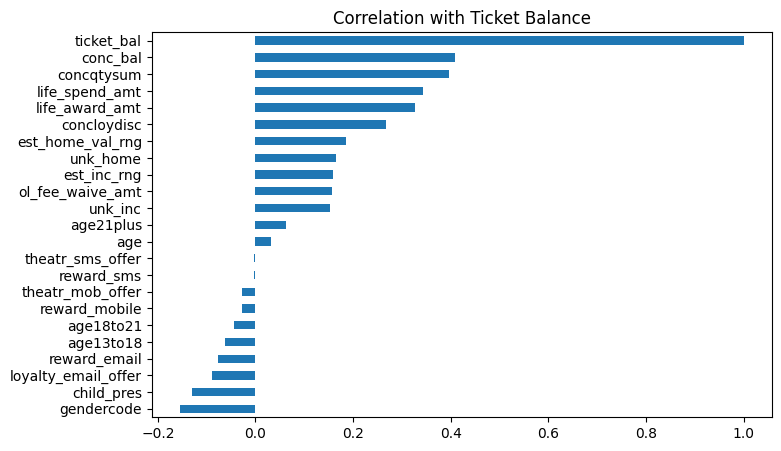

In [51]:
plt.figure(figsize=(8, 5))
data_reg.corr(numeric_only=True)['ticket_bal'].sort_values(ascending=True).plot(kind='barh')
plt.title('Correlation with Ticket Balance')
plt.show();

<Figure size 800x600 with 0 Axes>

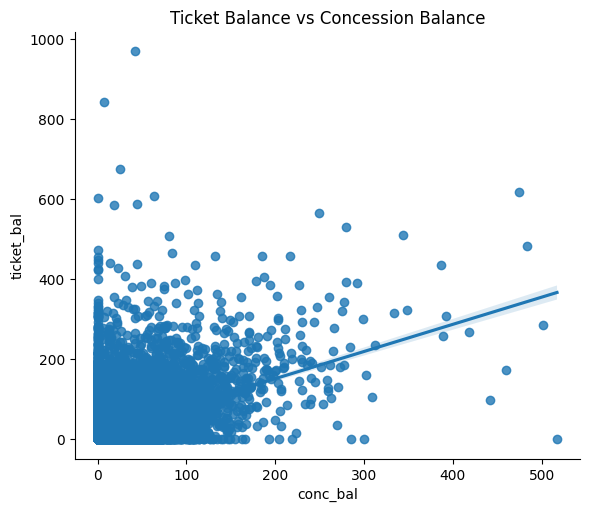

In [52]:
plt.figure(figsize=(8, 6))
sns.lmplot(x='conc_bal', y='ticket_bal', data=data_reg, height=5, aspect=1.2)
plt.title('Ticket Balance vs Concession Balance')
plt.show();

<Figure size 800x600 with 0 Axes>

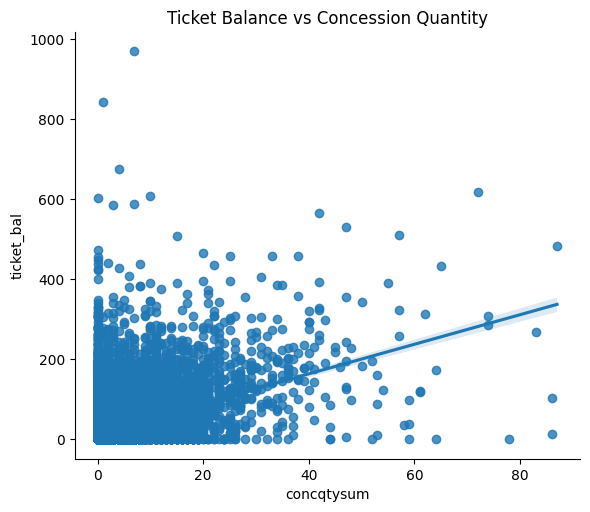

In [53]:
plt.figure(figsize=(8, 6))
sns.lmplot(x='concqtysum', y='ticket_bal', data=data_reg, height=5, aspect=1.2)
plt.title('Ticket Balance vs Concession Quantity')
plt.show();

In [54]:
X = data_reg.drop(columns=['ticket_bal'])
y = data_reg['ticket_bal']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r_squared_lr = r2_score(y_test, y_pred_lr)

print('Linear Regression coefficients:')
print(pd.Series(lr.coef_, index=X.columns).sort_values(ascending=False))
print('Intercept:', lr.intercept_)
print('Linear Regression MSE:', mse_lr)
print('Linear Regression RMSE:', rmse_lr)
print('Linear Regression R-squared:', r_squared_lr)

Linear Regression coefficients:
concloydisc             4.350715
unk_inc                 1.340543
est_home_val_rng        1.011978
child_pres              0.874942
conc_bal                0.454333
life_spend_amt          0.399718
ol_fee_waive_amt        0.103190
concqtysum              0.101415
theatr_mob_offer       -0.021626
age                    -0.031132
est_inc_rng            -0.243356
reward_mobile          -1.696783
reward_email           -2.493221
life_award_amt         -3.540890
gendercode             -3.985017
age21plus              -7.309768
unk_home               -7.423636
loyalty_email_offer    -9.023028
age18to21             -10.088222
age13to18             -14.153853
reward_sms            -25.457812
theatr_sms_offer      -25.457812
dtype: float64
Intercept: 39.66880294801392
Linear Regression MSE: 1034.9317911865573
Linear Regression RMSE: 32.17035578271644
Linear Regression R-squared: 0.2852566052970288


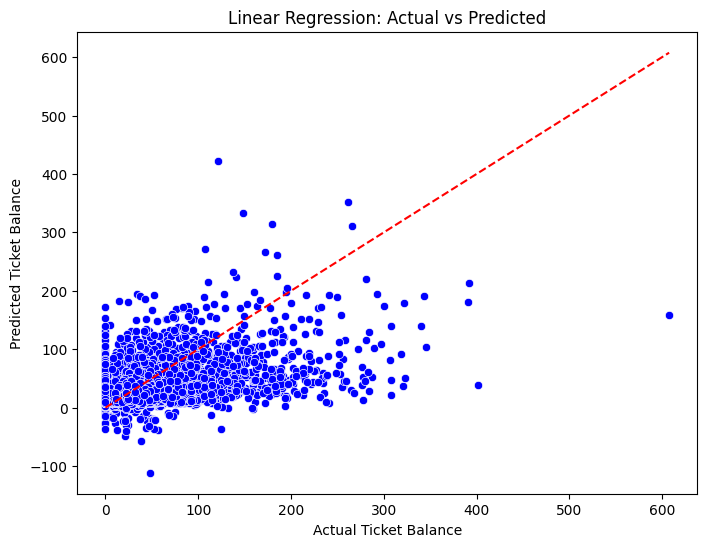

In [55]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_lr, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Linear Regression: Actual vs Predicted')
plt.xlabel('Actual Ticket Balance')
plt.ylabel('Predicted Ticket Balance')
plt.show();

In [56]:
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
scaler_reg = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[num_cols] = scaler_reg.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler_reg.transform(X_test[num_cols])

X_train_sm = sm.add_constant(X_train_scaled)
X_test_sm = sm.add_constant(X_test_scaled)
model_w_datapreprocessing = sm.OLS(y_train, X_train_sm).fit()

print(model_w_datapreprocessing.summary())

                            OLS Regression Results                            
Dep. Variable:             ticket_bal   R-squared:                       0.312
Model:                            OLS   Adj. R-squared:                  0.312
Method:                 Least Squares   F-statistic:                     700.1
Date:                Mon, 01 Jun 2026   Prob (F-statistic):               0.00
Time:                        22:49:57   Log-Likelihood:            -1.6007e+05
No. Observations:               32431   AIC:                         3.202e+05
Df Residuals:                   32409   BIC:                         3.204e+05
Df Model:                          21                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  23.2577    

In [57]:
y_pred_sm = model_w_datapreprocessing.predict(X_test_sm)

mse_sm = mean_squared_error(y_test, y_pred_sm)
rmse_sm = np.sqrt(mse_sm)
r_squared_sm = model_w_datapreprocessing.rsquared

print('Standardized OLS MSE:', mse_sm)
print('Standardized OLS RMSE:', rmse_sm)
print('Standardized OLS R-squared:', r_squared_sm)

Standardized OLS MSE: 1034.9317911865082
Standardized OLS RMSE: 32.17035578271568
Standardized OLS R-squared: 0.31206869935991044


### Lasso coefficients:

In [58]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)
y_pred_lasso = lasso.predict(X_test_scaled)

coefficients_lasso = pd.Series(lasso.coef_, index=X.columns)
print(coefficients_lasso)

age21plus               0.000000
age18to21              -0.543988
age13to18              -1.244016
gendercode             -4.289332
loyalty_email_offer    -3.631797
reward_email           -0.806176
reward_mobile          -0.636503
reward_sms             -0.129366
theatr_mob_offer       -0.082172
theatr_sms_offer       -0.000588
life_award_amt        -64.923315
life_spend_amt         73.200672
ol_fee_waive_amt        2.859608
est_inc_rng            -0.015237
est_home_val_rng        3.925421
child_pres              0.640451
concqtysum              0.460163
concloydisc             4.345747
conc_bal               11.364541
unk_inc                -0.043866
unk_home               -2.135390
age                    -0.376205
dtype: float64


In [59]:
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
r_squared_lasso = r2_score(y_test, y_pred_lasso)

print('Lasso MSE:', mse_lasso)
print('Lasso RMSE:', rmse_lasso)
print('Lasso R-squared:', r_squared_lasso)

Lasso MSE: 1037.321166175835
Lasso RMSE: 32.20747065784327
Lasso R-squared: 0.2836064579099272


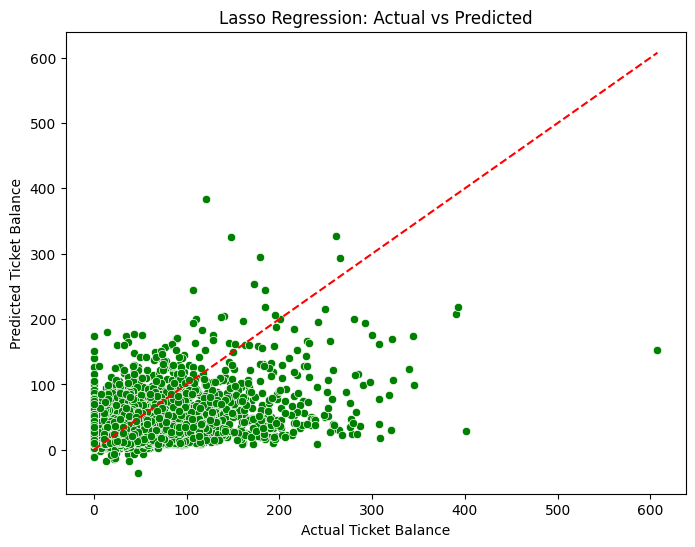

In [60]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_lasso, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Lasso Regression: Actual vs Predicted')
plt.xlabel('Actual Ticket Balance')
plt.ylabel('Predicted Ticket Balance')
plt.show();

### Top 5 regression features by F-score:

In [61]:
F_scores, p_values = f_regression(X, y)
feature_scores = pd.DataFrame({'Feature': X.columns, 'F_Score': F_scores, 'P_Value': p_values})
feature_scores = feature_scores.sort_values('F_Score', ascending=False)
top_features = feature_scores.nlargest(5, 'F_Score')['Feature']

print(list(top_features))

['conc_bal', 'concqtysum', 'life_spend_amt', 'life_award_amt', 'concloydisc']


In [62]:
after_selection = X[top_features]
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(after_selection, y, test_size=0.2, random_state=42)

X_train_new_scaled = scaler.fit_transform(X_train_new)
X_test_new_scaled = scaler.transform(X_test_new)
linear_model = LinearRegression()
linear_model.fit(X_train_new_scaled, y_train_new)
y_pred_selected = linear_model.predict(X_test_new_scaled)

mse_selected = mean_squared_error(y_test_new, y_pred_selected)
rmse_selected = np.sqrt(mse_selected)
r_squared_selected = r2_score(y_test_new, y_pred_selected)

print('Selected-feature Linear Regression MSE:', mse_selected)
print('Selected-feature Linear Regression RMSE:', rmse_selected)
print('Selected-feature Linear Regression R-squared:', r_squared_selected)


Selected-feature Linear Regression MSE: 1266.9280036803239
Selected-feature Linear Regression RMSE: 35.593932118836264
Selected-feature Linear Regression R-squared: 0.2206026829130726


### Selected-feature coefficients:'

In [63]:
print(pd.Series(linear_model.coef_, index=top_features))

Feature
conc_bal            9.817542
concqtysum          1.006869
life_spend_amt    124.729184
life_award_amt   -115.532188
concloydisc         4.504231
dtype: float64


In [64]:
X = data_reg.drop(columns=['ticket_bal'])
y = data_reg['ticket_bal']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train, y_train)
y_pred = rf_reg.predict(X_test)

mse_rf = mean_squared_error(y_test, y_pred)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred)

print('Random Forest Regressor MSE:', mse_rf)
print('Random Forest Regressor RMSE:', rmse_rf)
print('Random Forest Regressor R-squared:', r2_rf)

Random Forest Regressor MSE: 764.0174794210449
Random Forest Regressor RMSE: 27.640866111991585
Random Forest Regressor R-squared: 0.5299865722926027


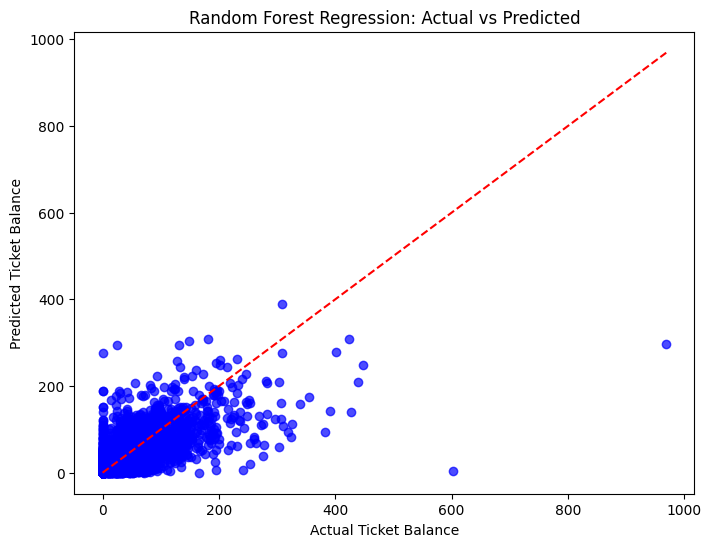

In [65]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Random Forest Regression: Actual vs Predicted')
plt.xlabel('Actual Ticket Balance')
plt.ylabel('Predicted Ticket Balance')
plt.show();

### Selected features from RFE:

In [66]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

rf_model = RandomForestRegressor(n_estimators=10, random_state=42)
rfe = RFE(estimator=rf_model, n_features_to_select=10)
rfe.fit(X_train_scaled, y_train)

selected_features = X.columns[rfe.support_]
print(list(selected_features))

['gendercode', 'life_award_amt', 'life_spend_amt', 'ol_fee_waive_amt', 'est_inc_rng', 'est_home_val_rng', 'concqtysum', 'concloydisc', 'conc_bal', 'age']


In [67]:
X_train_selected = X_train_scaled[:, rfe.support_]
X_test_selected = X_test_scaled[:, rfe.support_]

rf_reg = RandomForestRegressor(n_estimators=10, random_state=42)
rf_reg.fit(X_train_selected, y_train)
y_pred_2 = rf_reg.predict(X_test_selected)

mse_rf_selected = mean_squared_error(y_test, y_pred_2)
rmse_rf_selected = np.sqrt(mse_rf_selected)
r2_rf_selected = r2_score(y_test, y_pred_2)

print('Random Forest with selected features MSE:', mse_rf_selected)
print('Random Forest with selected features RMSE:', rmse_rf_selected)
print('Random Forest with selected features R-squared:', r2_rf_selected)

Random Forest with selected features MSE: 825.2356232882564
Random Forest with selected features RMSE: 28.726914614839103
Random Forest with selected features R-squared: 0.49232598151827045


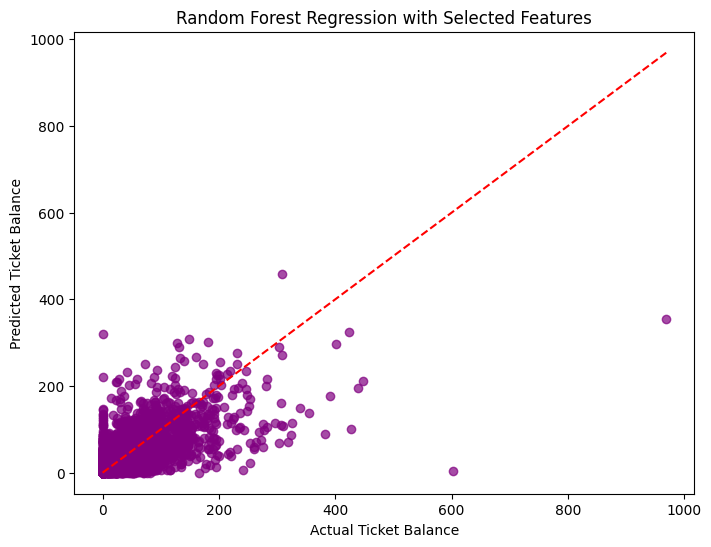

In [68]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_2, alpha=0.7, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Random Forest Regression with Selected Features')
plt.xlabel('Actual Ticket Balance')
plt.ylabel('Predicted Ticket Balance')
plt.show();

### Regression Interpretation

The regression models show how strongly ticket balance is tied to customer engagement. Linear and regularized linear models provide interpretable baselines, while the random forest captures non-linear patterns more effectively. In the original analysis, the tree-based regression approach performed best after feature selection, which suggests that ticket balance is influenced by interacting behavioral signals rather than by one or two variables alone.


## Clustering & Customer Segmentation

The final modeling step groups customers into segments using the behavioral fields. This helps translate the predictive work into practical customer profiles that can be used for targeting and campaign design.


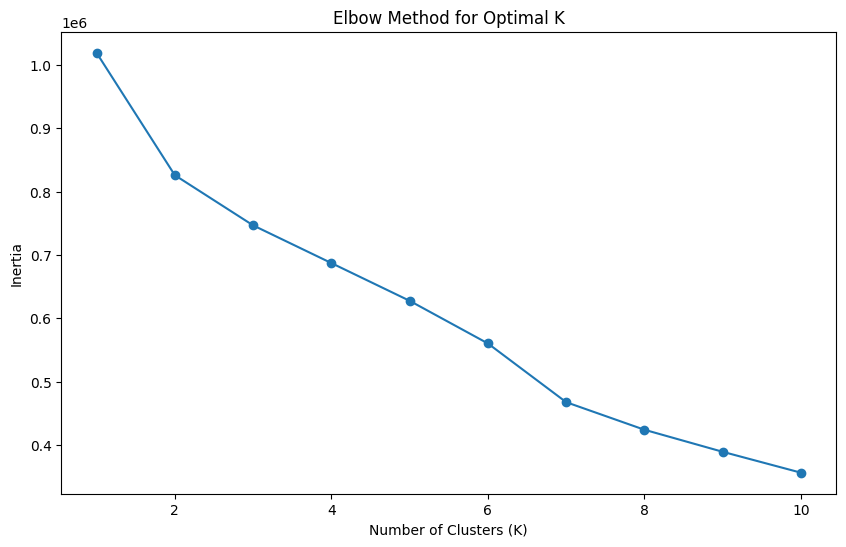

In [69]:
clustering_data = data_reg.drop(columns=['ticket_bal'], errors='ignore')
scaler = StandardScaler()
clustering_data_scaled = scaler.fit_transform(clustering_data)

k_values = list(range(1, 11))
inertia = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(clustering_data_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_values, inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.show()

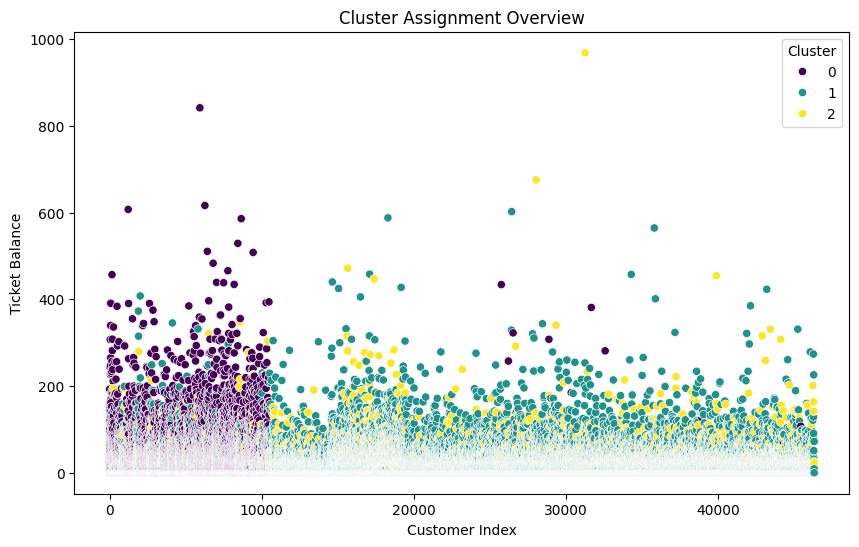

In [70]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(clustering_data_scaled)

data_with_clusters = data_reg.copy()
data_with_clusters['Cluster'] = clusters

plt.figure(figsize=(10, 6))
sns.scatterplot(x=data_with_clusters.index, y=data_with_clusters['ticket_bal'], hue=data_with_clusters['Cluster'], palette='viridis')
plt.title('Cluster Assignment Overview')
plt.xlabel('Customer Index')
plt.ylabel('Ticket Balance')
plt.show()

In [71]:
X_clf = clustering_data_scaled
y_clf = clusters
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X_clf, y_clf, test_size=0.3, random_state=42)

dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_train_clf, y_train_clf)
y_pred_clf = dt_clf.predict(X_test_clf)
accuracy_dt = accuracy_score(y_test_clf, y_pred_clf)

print('Decision Tree Accuracy for cluster explanation:', accuracy_dt)

Decision Tree Accuracy for cluster explanation: 0.9940287769784173


### Decision Tree for Cluster Interpretation

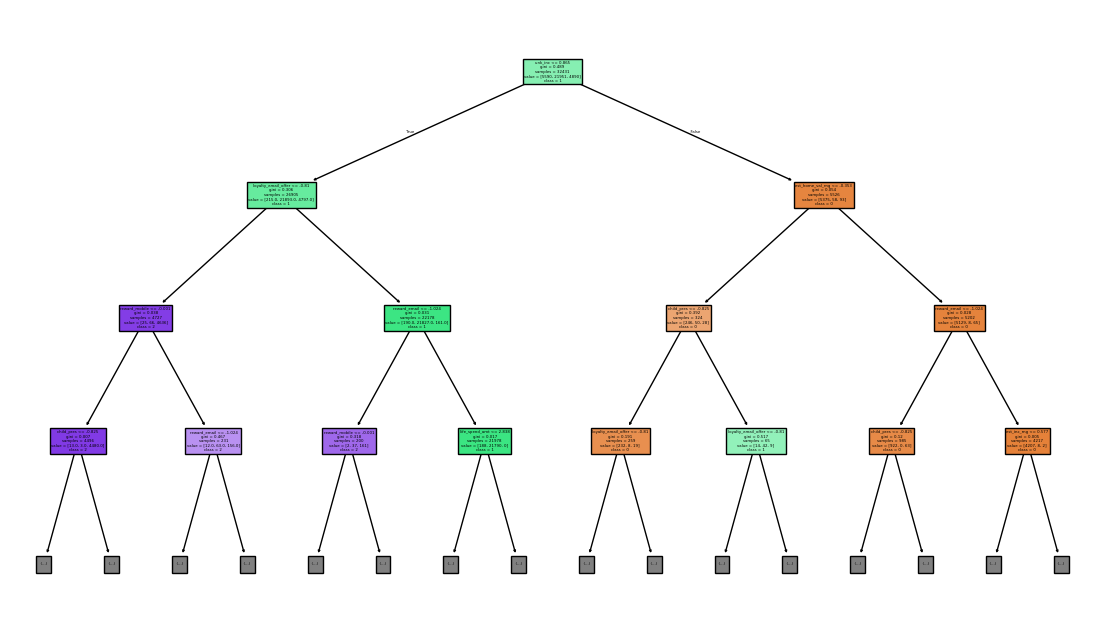

In [72]:
plt.figure(figsize=(14, 8))
plot_tree(dt_clf, feature_names=clustering_data.columns, class_names=[str(i) for i in np.unique(y_clf)], filled=True, max_depth=3)
plt.show()

### Cluster decision rules (simplified):

In [73]:
print(export_text(dt_clf, feature_names=list(clustering_data.columns), max_depth=3))

|--- unk_inc <= 0.87
|   |--- loyalty_email_offer <= -0.81
|   |   |--- reward_mobile <= -0.00
|   |   |   |--- child_pres <= -0.82
|   |   |   |   |--- truncated branch of depth 6
|   |   |   |--- child_pres >  -0.82
|   |   |   |   |--- truncated branch of depth 5
|   |   |--- reward_mobile >  -0.00
|   |   |   |--- reward_email <= -1.02
|   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- reward_email >  -1.02
|   |   |   |   |--- truncated branch of depth 3
|   |--- loyalty_email_offer >  -0.81
|   |   |--- reward_email <= -1.02
|   |   |   |--- reward_mobile <= -0.00
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- reward_mobile >  -0.00
|   |   |   |   |--- truncated branch of depth 4
|   |   |--- reward_email >  -1.02
|   |   |   |--- life_spend_amt <= 2.84
|   |   |   |   |--- truncated branch of depth 13
|   |   |   |--- life_spend_amt >  2.84
|   |   |   |   |--- truncated branch of depth 5
|--- unk_inc >  0.87
|   |--- est_home_val_rng <= -0.35


### Cluster profiles:

In [74]:
cluster_profiles = data_with_clusters.groupby('Cluster').mean(numeric_only=True)
cluster_profiles['Cluster Size'] = data_with_clusters['Cluster'].value_counts().sort_index()
cluster_profiles

,age21plus,age18to21,age13to18,gendercode,loyalty_email_offer,reward_email,reward_mobile,reward_sms,theatr_mob_offer,theatr_sms_offer,...,est_home_val_rng,child_pres,ticket_bal,concqtysum,concloydisc,conc_bal,unk_inc,unk_home,age,Cluster Size
Cluster,,,,,,,,,,,,,,,,,,,,,
0,0.941489,0.035057,0.014566,1.882484,0.780521,0.827182,0.267498,0.000247,0.278114,0.000247,...,9.860511,1.166646,38.588534,3.265152,0.460206,18.651262,0.961857,0.956919,50.985064,8101
1,0.881152,0.068644,0.045794,2.602550,0.996740,0.998051,0.664643,0.000000,0.669181,0.000000,...,0.427394,2.995590,18.399609,2.014029,0.162756,11.629897,0.002525,0.051419,47.103285,31292
2,0.897809,0.070049,0.029259,2.442346,0.033151,0.260017,0.032286,0.000000,0.033295,0.000000,...,0.922456,2.980542,27.746291,0.484145,0.069792,2.760713,0.019458,0.105074,44.941770,6938


In [75]:
for cluster in cluster_profiles.index:
    print(f'Cluster {cluster} summary:')
    print(cluster_profiles.loc[cluster].drop('Cluster Size'))

Cluster 0 summary:
age21plus                0.941489
age18to21                0.035057
age13to18                0.014566
gendercode               1.882484
loyalty_email_offer      0.780521
reward_email             0.827182
reward_mobile            0.267498
reward_sms               0.000247
theatr_mob_offer         0.278114
theatr_sms_offer         0.000247
life_award_amt          25.002779
life_spend_amt         245.399543
ol_fee_waive_amt         6.326009
est_inc_rng              5.990865
est_home_val_rng         9.860511
child_pres               1.166646
ticket_bal              38.588534
concqtysum               3.265152
concloydisc              0.460206
conc_bal                18.651262
unk_inc                  0.961857
unk_home                 0.956919
age                     50.985064
Name: 0, dtype: float64
Cluster 1 summary:
age21plus               0.881152
age18to21               0.068644
age13to18               0.045794
gendercode              2.602550
loyalty_email_offer     

## Insights, Conclusions, and Recommendations

### Key Findings
- Premier conversion is most strongly associated with spending and engagement behavior rather than age alone.
- Premier customers consistently show higher ticket quantity, concession balance, and lifetime spend.
- The random forest classifier is the strongest Premier prediction model in the original analysis, outperforming the decision tree and logistic regression.
- Regression models confirm that ticket balance is explainable using the same behavioral variables, with tree-based methods capturing the most useful non-linear structure.
- Clustering reveals distinct customer segments that can support different targeting strategies.

### Business Implications
- Focus Premier acquisition campaigns on customers with high spend and strong reward engagement.
- Use communication opt-ins as a practical signal for campaign readiness.
- Build retention and upsell programs around the high-value clusters identified in the segmentation step.

### Limitations
- The project uses only the existing fields in the provided dataset, so external factors such as visit frequency history outside the system are not included.
- Age is derived from birthdate at analysis time, so it changes as time passes.
- Some features are encoded categories, which limits interpretability of certain coefficients compared with richer behavioral histories.

### Next Steps
- Validate the models on a future holdout sample if one becomes available.
- Explore calibration and threshold tuning for Premier conversion.
- Combine segmentation with targeted campaign experiments to measure downstream lift.
